<a href="https://colab.research.google.com/github/SantiagoAviles/Rice-Proyect/blob/main/RiceModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data
## Grain Rice Type
- Entero -> Whole
- Mancha -> Stained
- Quebrado -> Broken
- Tiza -> Chalky

In [ ]:
# ============================================================
# BLOQUE 1: Clonar repositorio con Git LFS
# ============================================================

!git lfs install

# Si ya existe el directorio, lo elimina antes de clonar
import os, shutil
if os.path.exists('/content/Rice-Proyect'):
    shutil.rmtree('/content/Rice-Proyect')
    print("Previous directory removed")

# Clonar el repositorio con el dataset
!git clone https://github.com/SantiagoAviles/Rice-Proyect.git /content/Rice-Proyect

print("\nRepository contents:")
!ls -lh /content/Rice-Proyect/

print("\nDATASET/ contents:")
!ls -lh /content/Rice-Proyect/DATASET/

Git LFS initialized.
Cloning into '/content/Rice-Proyect'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 31 (delta 13), reused 12 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 10.72 KiB | 5.36 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Filtering content: 100% (2/2), 669.69 MiB | 13.08 MiB/s, done.

Repository contents:
total 16K
drwxr-xr-x 2 root root 4.0K Apr 17 05:25 DATASET
-rw-r--r-- 1 root root 1.1K Apr 17 05:24 LICENSE
-rw-r--r-- 1 root root 5.4K Apr 17 05:24 README.md

DATASET/ contents:
total 670M
-rw-r--r-- 1 root root 335M Apr 17 05:25 balanceado_aug.rar
-rw-r--r-- 1 root root 335M Apr 17 05:25 PeruvianRiceDataset.rar


In [ ]:
# ============================================================
# BLOQUE 2: Descomprimir PeruvianRiceDataset.rar
# ============================================================
import os

RAR_PATH    = '/content/Rice-Proyect/DATASET/PeruvianRiceDataset.rar'
EXTRACT_DIR = '/content/PeruvianRiceDataset/'

os.makedirs(EXTRACT_DIR, exist_ok=True)

size_mb = os.path.getsize(RAR_PATH) / (1024**2)
print(f"✔ File found: {RAR_PATH}")
print(f"  Size: {size_mb:.1f} MB")

print("\nInstalling unrar...")
!apt-get install -y unrar -q
print("✔ unrar installed")

print("\nExtracting (this may take 1-2 minutes)...")
!unrar x -y "{RAR_PATH}" "{EXTRACT_DIR}"

print("\nExtracted structure:")
!find {EXTRACT_DIR} -maxdepth 4 -type d | sort

Se truncaron las últimas líneas 5000 del resultado de transmisión.
Extracting  /content/PeruvianRiceDataset/PeruvianRiceDataset/train/quebrado/q_0_645.png      59%  OK 
Extracting  /content/PeruvianRiceDataset/PeruvianRiceDataset/train/quebrado/q_0_6452.png      59%  OK 
Extracting  /content/PeruvianRiceDataset/PeruvianRiceDataset/train/quebrado/q_0_6455.png      59%  OK 
Extracting  /content/PeruvianRiceDataset/PeruvianRiceDataset/train/quebrado/q_0_6458.png      60%  OK 
Extracting  /content/PeruvianRiceDataset/PeruvianRiceDataset/train/quebrado/q_0_6459.png      60%  OK 
Extracting  /content/PeruvianRiceDataset/PeruvianRiceDataset/train/quebrado/q_0_646.png      60%  OK 
Extracting  /content/PeruvianRiceDataset/PeruvianRiceDataset/train/quebrado/q_0_6462.png      60%  OK 
Extracting  /content/PeruvianRiceDataset/PeruvianRiceDataset/train/quebrado/q_0_6465.png      60%  OK 
Extracting  /content/PeruvianRiceDatase

In [ ]:
# ============================================================
# BLOQUE 3: Verificar estructura train / val / test
# ============================================================
import os

# Ruta raiz donde se encuentran train/ val/ test/
SPLIT_DIR = '/content/PeruvianRiceDataset/PeruvianRiceDataset'

SUBSETS = ['train', 'val', 'test']
CLASES  = ['entero', 'mancha', 'quebrado', 'tiza']

# Verificar que las 3 carpetas existen
for subset in SUBSETS:
    path = os.path.join(SPLIT_DIR, subset)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing folder: {path}")

print(f"Split found at: {SPLIT_DIR}\n")

# Tabla de distribucion
print("=" * 58)
print(f"  {'DATASET DISTRIBUTION':^54}")
print("=" * 58)
print(f"  {'Class':<12}  {'Train':>8}  {'Val':>8}  {'Test':>8}  {'Total':>8}")
print("-" * 58)

totales = {'train': 0, 'val': 0, 'test': 0}
for clase in CLASES:
    counts = {}
    for subset in SUBSETS:
        folder = os.path.join(SPLIT_DIR, subset, clase)
        n = len(os.listdir(folder)) if os.path.exists(folder) else 0
        counts[subset] = n
        totales[subset] += n
    total_clase = sum(counts.values())
    print(f"  {clase:<12}  {counts['train']:>8}  "
          f"{counts['val']:>8}  {counts['test']:>8}  {total_clase:>8}")

print("-" * 58)
print(f"  {'TOTAL':<12}  {totales['train']:>8}  "
      f"{totales['val']:>8}  {totales['test']:>8}  "
      f"{sum(totales.values()):>8}")
print("=" * 58)


Split found at: /content/PeruvianRiceDataset/PeruvianRiceDataset

                   DATASET DISTRIBUTION                 
  Class            Train       Val      Test     Total
----------------------------------------------------------
  entero            2345       502       504      3351
  mancha            2300       492       494      3286
  quebrado          2290       490       492      3272
  tiza              2325       498       499      3322
----------------------------------------------------------
  TOTAL             9260      1982      1989     13231


In [ ]:
# ============================================================
# BLOQUE 4: Importaciones globales e hiperparámetros compartidos
# ============================================================
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                        ReduceLROnPlateau, Callback)
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense,
                                     Dropout, BatchNormalization)
from sklearn.metrics import classification_report, confusion_matrix
warnings.filterwarnings('ignore')

# ── Hiperparámetros globales (compartidos por todos los modelos) ──
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 1e-4
SEED       = 42

# ── Rutas del dataset ────────────────────────────────────────
SPLIT_DIR  = '/content/PeruvianRiceDataset/PeruvianRiceDataset'
TRAIN_DIR  = os.path.join(SPLIT_DIR, 'train')
VAL_DIR    = os.path.join(SPLIT_DIR, 'val')
TEST_DIR   = os.path.join(SPLIT_DIR, 'test')

# ── Generadores de imágenes (sin augmentation: el dataset ya lo tiene) ──
datagen = ImageDataGenerator(rescale=1.0 / 255)

train_data = datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)
val_data = datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, seed=SEED
)
test_data = datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, seed=SEED
)

NUM_CLASSES  = len(train_data.class_indices)
CLASS_NAMES  = list(train_data.class_indices.keys())

print(f"TensorFlow version : {tf.__version__}")
print(f"GPUs available     : {tf.config.list_physical_devices('GPU')}")
print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Images  -> Train: {train_data.n} | Val: {val_data.n} | Test: {test_data.n}")

# ── Función auxiliar: construir callbacks globales por modelo ──
def get_callbacks(model_name: str):
    """Devuelve EarlyStopping, ReduceLROnPlateau y ModelCheckpoint."""
    return [
        EarlyStopping(monitor='val_loss', patience=4,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, min_lr=1e-7, verbose=1),
        ModelCheckpoint(f'best_{model_name}.keras',
                        monitor='val_accuracy', save_best_only=True, verbose=0)
    ]

# ── Función auxiliar: graficar accuracy y loss por separado ──
def plot_history(history, model_name: str):
    """Genera dos figuras separadas: Accuracy y Loss (Training vs Validation)."""
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_r = range(1, len(acc) + 1)

    # -- Figura 1: Accuracy --
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_r, acc,     color='steelblue', linewidth=2,
             marker='o', markersize=4, label='Training Accuracy')
    plt.plot(epochs_r, val_acc, color='darkorange', linewidth=2,
             marker='s', markersize=4, label='Validation Accuracy')
    plt.title(f'{model_name} — Accuracy: Training vs Validation', fontsize=13, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # -- Figura 2: Loss --
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_r, loss,     color='steelblue', linewidth=2,
             marker='o', markersize=4, label='Training Loss')
    plt.plot(epochs_r, val_loss, color='darkorange', linewidth=2,
             marker='s', markersize=4, label='Validation Loss')
    plt.title(f'{model_name} — Loss: Training vs Validation', fontsize=13, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# ── Función auxiliar: evaluación final en test ──────────────
def evaluate_on_test(model, model_name: str):
    """Evalúa el modelo en el set de prueba e imprime resultados."""
    test_data.reset()
    test_loss, test_acc = model.evaluate(test_data, verbose=0)
    print(f"\n{'='*55}")
    print(f"  {model_name} — FINAL TEST RESULTS")
    print(f"{'='*55}")
    print(f"  Test Accuracy : {test_acc * 100:.2f}%")
    print(f"  Test Loss     : {test_loss:.4f}")
    print(f"{'='*55}")

    # Predicciones para reporte y matriz de confusión
    test_data.reset()
    y_probs = model.predict(test_data, verbose=0)
    y_pred  = np.argmax(y_probs, axis=1)
    y_true  = test_data.classes

    print(f"\nClassification Report ({model_name}):")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix — {model_name} (Test Set)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

print("\nGlobal setup complete. Ready to train models.")

Found 9260 images belonging to 4 classes.
Found 1982 images belonging to 4 classes.
Found 1989 images belonging to 4 classes.
TensorFlow version : 2.19.0
GPUs available     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Classes (4): ['entero', 'mancha', 'quebrado', 'tiza']
Images  -> Train: 9260 | Val: 1982 | Test: 1989

Global setup complete. Ready to train models.


# MobileNetV2

In [ ]:
# ============================================================
# MODELO 1: Arquitectura MobileNetV2
# ============================================================
from tensorflow.keras.applications import MobileNetV2

# Cargar base preentrenada con ImageNet, sin cabezal
base_mobilenet = MobileNetV2(
    input_shape = IMG_SIZE + (3,),
    include_top = False,
    weights     = 'imagenet'
)
base_mobilenet.trainable = False  # Congelar base

# Cabezal de clasificación acordado por el equipo
x = base_mobilenet.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output_mob = Dense(NUM_CLASSES, activation='softmax')(x)

model_mobilenet = Model(inputs=base_mobilenet.input, outputs=output_mob)

# Compilar con hiperparámetros globales
model_mobilenet.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=LR),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

trainable = sum(tf.size(w).numpy() for w in model_mobilenet.trainable_weights)
total     = model_mobilenet.count_params()
print(f"MobileNetV2 — Total params: {total:,} | Trainable: {trainable:,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 — Total params: 2,620,356 | Trainable: 361,860


In [ ]:
# ============================================================
# MODELO 1: Entrenamiento MobileNetV2
# ============================================================
print("--- STARTING TRAINING: MobileNetV2 ---")
history_mobilenet = model_mobilenet.fit(
    train_data,
    epochs          = EPOCHS,
    validation_data = val_data,
    callbacks       = get_callbacks('mobilenetv2')
)
print("--- TRAINING COMPLETE: MobileNetV2 ---")


--- STARTING TRAINING: MobileNetV2 ---
Epoch 1/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 90s 239ms/step - accuracy: 0.7398 - loss: 0.6858 - val_accuracy: 0.8507 - val_loss: 0.3894 - learning_rate: 1.0000e-04
Epoch 2/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 34s 116ms/step - accuracy: 0.8276 - loss: 0.4400 - val_accuracy: 0.8643 - val_loss: 0.3343 - learning_rate: 1.0000e-04
Epoch 3/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 42s 144ms/step - accuracy: 0.8532 - loss: 0.3657 - val_accuracy: 0.8804 - val_loss: 0.3157 - learning_rate: 1.0000e-04
Epoch 4/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 34s 118ms/step - accuracy: 0.8636 - loss: 0.3433 - val_accuracy: 0.8860 - val_loss: 0.2921 - learning_rate: 1.0000e-04
Epoch 5/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 35s 121ms/step - accuracy: 0.8707 - loss: 0.3198 - val_accuracy: 0.8885 - val_loss: 0.2924 - learning_rate: 1.0000e-04
Epoch 6/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 34s 117ms/step - accuracy: 0.8792 - loss: 0.3012 - val_accuracy: 0.8905 - val_loss: 0.2751 - learning_rate: 1.0000e-04
Epoch 7

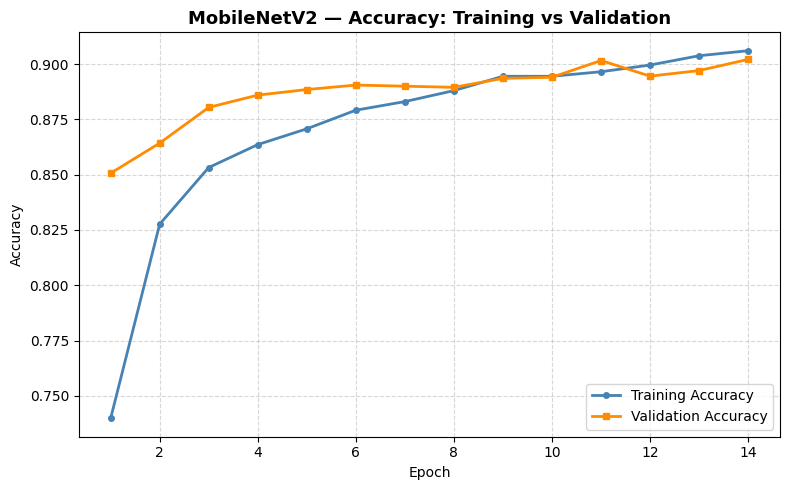

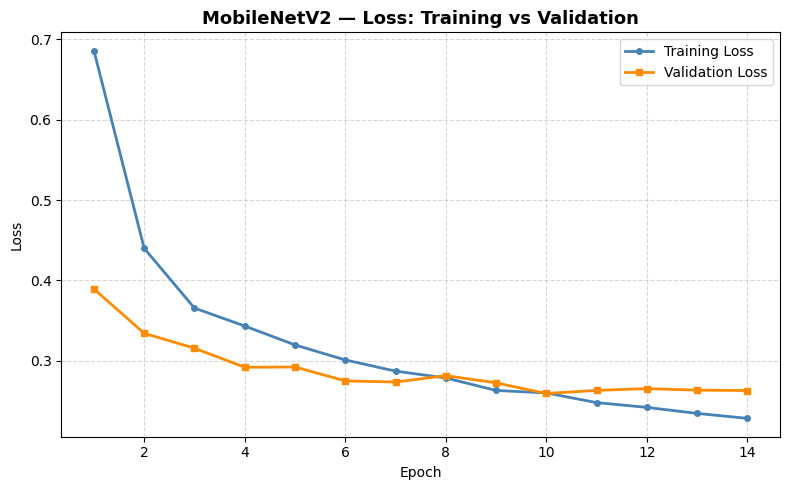


  MobileNetV2 — FINAL TEST RESULTS
  Test Accuracy : 89.09%
  Test Loss     : 0.2486

Classification Report (MobileNetV2):
              precision    recall  f1-score   support

      entero       0.78      0.84      0.81       504
      mancha       0.96      0.94      0.95       494
    quebrado       0.96      0.99      0.97       492
        tiza       0.87      0.81      0.84       499

    accuracy                           0.89      1989
   macro avg       0.89      0.89      0.89      1989
weighted avg       0.89      0.89      0.89      1989



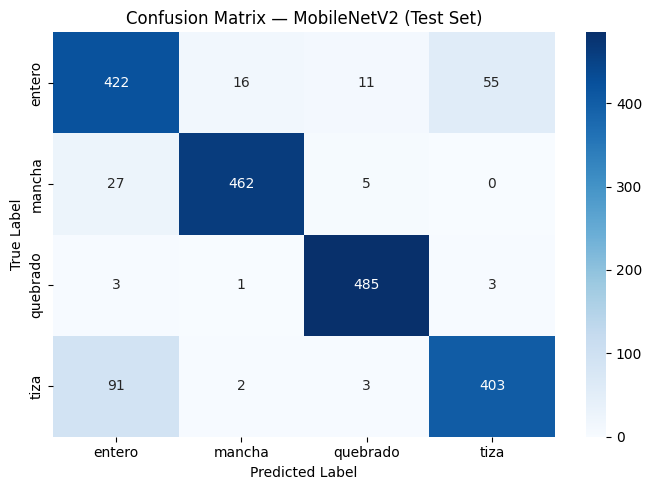

In [ ]:
# ============================================================
# MODELO 1: Gráficas y evaluación final — MobileNetV2
# ============================================================
# Dos figuras separadas: Accuracy y Loss
plot_history(history_mobilenet, 'MobileNetV2')

# Evaluación única y definitiva sobre el set de prueba
evaluate_on_test(model_mobilenet, 'MobileNetV2')

#EfficientNetB0

In [ ]:
# ============================================================
# MODELO 2: Arquitectura EfficientNetB0
# ============================================================
from tensorflow.keras.applications import EfficientNetB0

# Cargar base preentrenada con ImageNet, sin cabezal
base_efficient = EfficientNetB0(
    input_shape = IMG_SIZE + (3,),
    include_top = False,
    weights     = 'imagenet'
)
base_efficient.trainable = False  # Congelar base

# Cabezal de clasificación acordado por el equipo
x = base_efficient.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output_eff = Dense(NUM_CLASSES, activation='softmax')(x)

model_efficient = Model(inputs=base_efficient.input, outputs=output_eff)

# Compilar con hiperparámetros globales
model_efficient.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=LR),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

trainable = sum(tf.size(w).numpy() for w in model_efficient.trainable_weights)
total     = model_efficient.count_params()
print(f"EfficientNetB0 — Total params: {total:,} | Trainable: {trainable:,}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 — Total params: 4,411,943 | Trainable: 361,860


In [ ]:
# ============================================================
# MODELO 2: GENERADOR SOLO PARA EFFICIENTNET
# ============================================================

from tensorflow.keras.applications.efficientnet import preprocess_input

datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data_eff = datagen_eff.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)

val_data_eff = datagen_eff.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, seed=SEED
)

test_data_eff = datagen_eff.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, seed=SEED
)

Found 9260 images belonging to 4 classes.
Found 1982 images belonging to 4 classes.
Found 1989 images belonging to 4 classes.


In [ ]:
# ============================================================
# MODELO 2: Entrenamiento EfficientNetB0
# ============================================================
print("--- STARTING TRAINING: EfficientNetB0 ---")
history_efficient = model_efficient.fit(
    train_data_eff,
    epochs          = EPOCHS,
    validation_data = val_data_eff,
    callbacks       = get_callbacks('efficientnetb0')
)
print("--- TRAINING COMPLETE: EfficientNetB0 ---")

--- STARTING TRAINING: EfficientNetB0 ---
Epoch 1/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 101s 260ms/step - accuracy: 0.7592 - loss: 0.6337 - val_accuracy: 0.8683 - val_loss: 0.3413 - learning_rate: 1.0000e-04
Epoch 2/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 35s 121ms/step - accuracy: 0.8468 - loss: 0.3900 - val_accuracy: 0.8855 - val_loss: 0.2888 - learning_rate: 1.0000e-04
Epoch 3/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 36s 124ms/step - accuracy: 0.8664 - loss: 0.3394 - val_accuracy: 0.8910 - val_loss: 0.2689 - learning_rate: 1.0000e-04
Epoch 4/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 34s 117ms/step - accuracy: 0.8726 - loss: 0.3171 - val_accuracy: 0.8860 - val_loss: 0.2676 - learning_rate: 1.0000e-04
Epoch 5/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 39s 133ms/step - accuracy: 0.8760 - loss: 0.2954 - val_accuracy: 0.8935 - val_loss: 0.2547 - learning_rate: 1.0000e-04
Epoch 6/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 35s 121ms/step - accuracy: 0.8822 - loss: 0.2900 - val_accuracy: 0.8961 - val_loss: 0.2506 - learning_rate: 1.0000e-04
Epo

In [ ]:
# ============================================================
# MODELO 2: Evaluacion final en test de EfficientNetB0
# ============================================================
def evaluate_on_test_eff(model, model_name: str):
    test_data_eff.reset()
    test_loss, test_acc = model.evaluate(test_data_eff, verbose=0)

    print(f"\n{'='*55}")
    print(f"  {model_name} — FINAL TEST RESULTS")
    print(f"{'='*55}")
    print(f"  Test Accuracy : {test_acc * 100:.2f}%")
    print(f"  Test Loss     : {test_loss:.4f}")
    print(f"{'='*55}")

    test_data_eff.reset()
    y_probs = model.predict(test_data_eff, verbose=0)
    y_pred  = np.argmax(y_probs, axis=1)
    y_true  = test_data_eff.classes

    print(f"\nClassification Report ({model_name}):")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix — {model_name} (Test Set)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

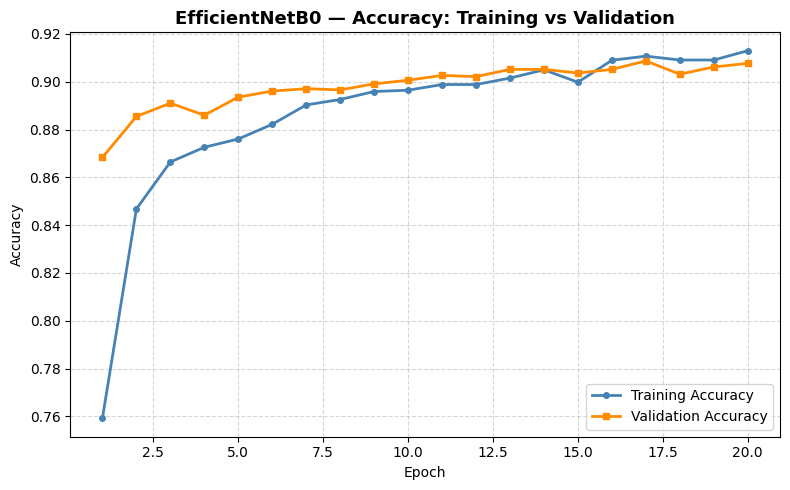

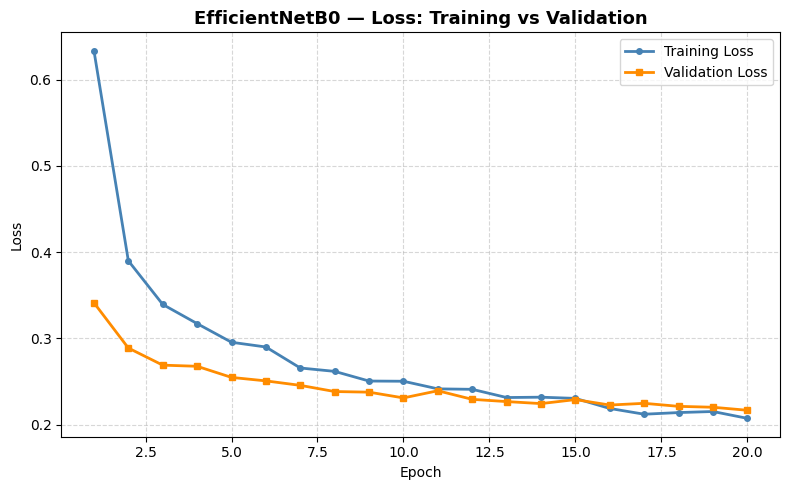


  EfficientNetB0 — FINAL TEST RESULTS
  Test Accuracy : 91.20%
  Test Loss     : 0.2032

Classification Report (EfficientNetB0):
              precision    recall  f1-score   support

      entero       0.87      0.80      0.83       504
      mancha       0.98      0.97      0.97       494
    quebrado       0.97      0.98      0.97       492
        tiza       0.84      0.90      0.87       499

    accuracy                           0.91      1989
   macro avg       0.91      0.91      0.91      1989
weighted avg       0.91      0.91      0.91      1989



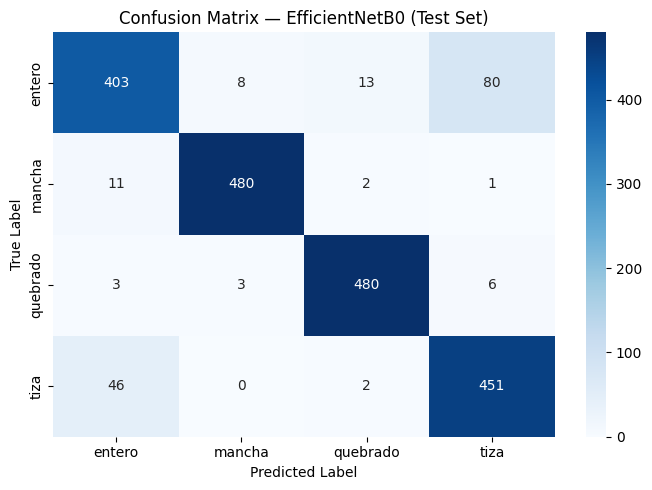

In [ ]:
# ============================================================
# MODELO 2: Gráficas y evaluación final — EfficientNetB0
# ============================================================
# Dos figuras separadas: Accuracy y Loss
plot_history(history_efficient, 'EfficientNetB0')

# Evaluación única y definitiva sobre el set de prueba
evaluate_on_test_eff(model_efficient, 'EfficientNetB0')


# ResNet50

In [ ]:
# ============================================================
# MODELO 3: Arquitectura ResNet50
# ============================================================
from tensorflow.keras.applications import ResNet50

# Cargar base preentrenada con ImageNet, sin cabezal
base_resnet = ResNet50(
    input_shape = IMG_SIZE + (3,),
    include_top = False,
    weights     = 'imagenet'
)
base_resnet.trainable = False  # Congelar base

# Cabezal de clasificación acordado por el equipo
x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output_res = Dense(NUM_CLASSES, activation='softmax')(x)

model_resnet = Model(inputs=base_resnet.input, outputs=output_res)

# Compilar con hiperparámetros globales
model_resnet.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=LR),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

trainable = sum(tf.size(w).numpy() for w in model_resnet.trainable_weights)
total     = model_resnet.count_params()
print(f"ResNet50 — Total params: {total:,} | Trainable: {trainable:,}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 — Total params: 24,146,692 | Trainable: 558,468


In [ ]:
# ============================================================
# MODELO 3: Entrenamiento ResNet50
# ============================================================
print("--- STARTING TRAINING: ResNet50 ---")
history_resnet = model_resnet.fit(
    train_data,
    epochs          = EPOCHS,
    validation_data = val_data,
    callbacks       = get_callbacks('resnet50')
)
print("--- TRAINING COMPLETE: ResNet50 ---")

--- STARTING TRAINING: ResNet50 ---
Epoch 1/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 77s 208ms/step - accuracy: 0.5816 - loss: 1.0001 - val_accuracy: 0.4864 - val_loss: 1.0882 - learning_rate: 1.0000e-04
Epoch 2/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 44s 151ms/step - accuracy: 0.6898 - loss: 0.7623 - val_accuracy: 0.7432 - val_loss: 0.7057 - learning_rate: 1.0000e-04
Epoch 3/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 43s 148ms/step - accuracy: 0.7231 - loss: 0.6754 - val_accuracy: 0.7200 - val_loss: 0.6267 - learning_rate: 1.0000e-04
Epoch 4/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 43s 148ms/step - accuracy: 0.7425 - loss: 0.6110 - val_accuracy: 0.7770 - val_loss: 0.5437 - learning_rate: 1.0000e-04
Epoch 5/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 43s 147ms/step - accuracy: 0.7563 - loss: 0.5885 - val_accuracy: 0.7578 - val_loss: 0.5811 - learning_rate: 1.0000e-04
Epoch 6/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 43s 147ms/step - accuracy: 0.7583 - loss: 0.5704 - val_accuracy: 0.7886 - val_loss: 0.5313 - learning_rate: 1.0000e-04
Epoch 7/20

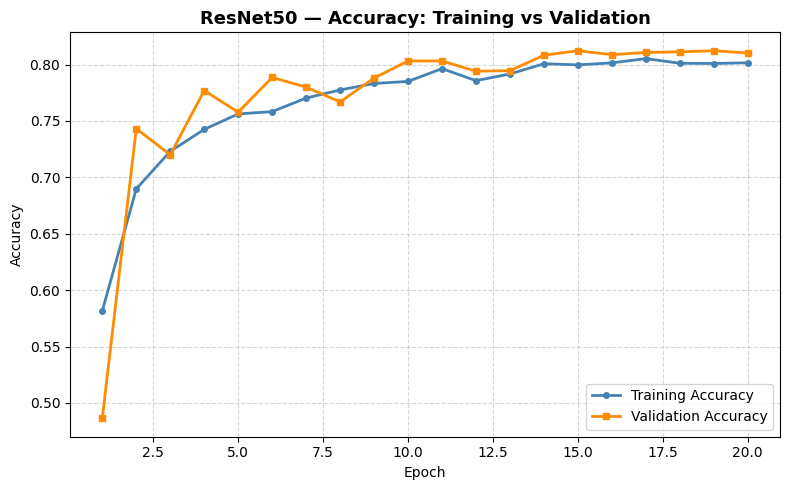

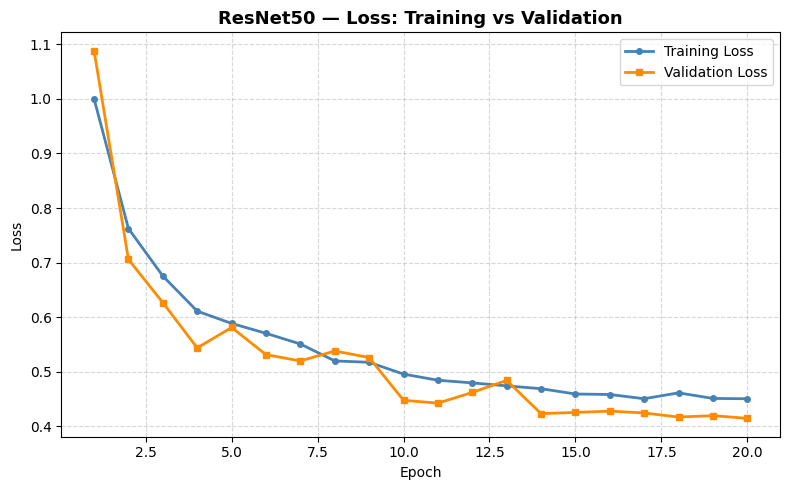


  ResNet50 — FINAL TEST RESULTS
  Test Accuracy : 80.39%
  Test Loss     : 0.4286

Classification Report (ResNet50):
              precision    recall  f1-score   support

      entero       0.62      0.82      0.71       504
      mancha       0.90      0.84      0.87       494
    quebrado       0.92      0.98      0.95       492
        tiza       0.86      0.58      0.69       499

    accuracy                           0.80      1989
   macro avg       0.82      0.80      0.80      1989
weighted avg       0.82      0.80      0.80      1989



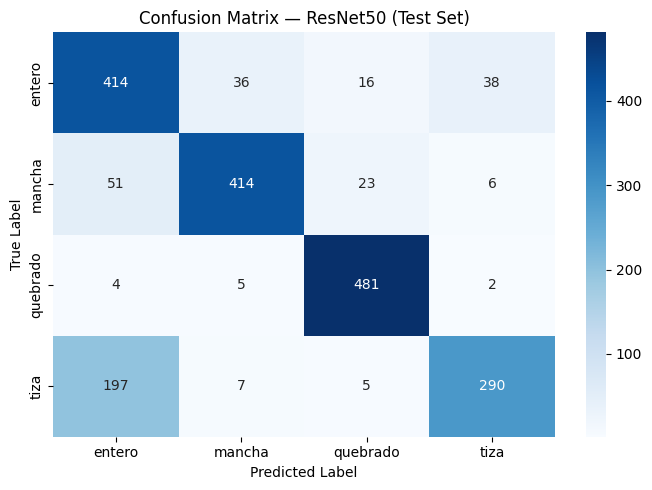

In [ ]:
# ============================================================
# MODELO 3: Gráficas y evaluación final — ResNet50
# ============================================================
# Dos figuras separadas: Accuracy y Loss
plot_history(history_resnet, 'ResNet50')

# Evaluación única y definitiva sobre el set de prueba
evaluate_on_test(model_resnet, 'ResNet50')

#DenseNet21

In [ ]:
# ============================================================
# MODELO 4: Arquitectura DenseNet121
# ============================================================
from tensorflow.keras.applications import DenseNet121

# Cargar base preentrenada con ImageNet, sin cabezal
base_dense = DenseNet121(
    input_shape = IMG_SIZE + (3,),
    include_top = False,
    weights     = 'imagenet'
)
base_dense.trainable = False  # Congelar base

# Cabezal de clasificación acordado por el equipo
x = base_dense.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output_den = Dense(NUM_CLASSES, activation='softmax')(x)

model_densenet = Model(inputs=base_dense.input, outputs=output_den)

# Compilar con hiperparámetros globales
model_densenet.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=LR),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

trainable = sum(tf.size(w).numpy() for w in model_densenet.trainable_weights)
total     = model_densenet.count_params()
print(f"DenseNet121 — Total params: {total:,} | Trainable: {trainable:,}")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
DenseNet121 — Total params: 7,334,340 | Trainable: 296,324


In [ ]:
# ============================================================
# MODELO 4: Entrenamiento DenseNet121
# ============================================================
print("--- STARTING TRAINING: DenseNet121 ---")
history_densenet = model_densenet.fit(
    train_data,
    epochs          = EPOCHS,
    validation_data = val_data,
    callbacks       = get_callbacks('densenet121')
)
print("--- TRAINING COMPLETE: DenseNet121 ---")

--- STARTING TRAINING: DenseNet121 ---
Epoch 1/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 119s 299ms/step - accuracy: 0.7161 - loss: 0.7618 - val_accuracy: 0.8486 - val_loss: 0.3819 - learning_rate: 1.0000e-04
Epoch 2/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 42s 146ms/step - accuracy: 0.8284 - loss: 0.4474 - val_accuracy: 0.8698 - val_loss: 0.3145 - learning_rate: 1.0000e-04
Epoch 3/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 42s 146ms/step - accuracy: 0.8509 - loss: 0.3856 - val_accuracy: 0.8845 - val_loss: 0.2801 - learning_rate: 1.0000e-04
Epoch 4/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 43s 149ms/step - accuracy: 0.8652 - loss: 0.3444 - val_accuracy: 0.8875 - val_loss: 0.2720 - learning_rate: 1.0000e-04
Epoch 5/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 43s 148ms/step - accuracy: 0.8755 - loss: 0.3176 - val_accuracy: 0.9026 - val_loss: 0.2515 - learning_rate: 1.0000e-04
Epoch 6/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 43s 148ms/step - accuracy: 0.8826 - loss: 0.2964 - val_accuracy: 0.9026 - val_loss: 0.2451 - learning_rate: 1.0000e-04
Epoch 

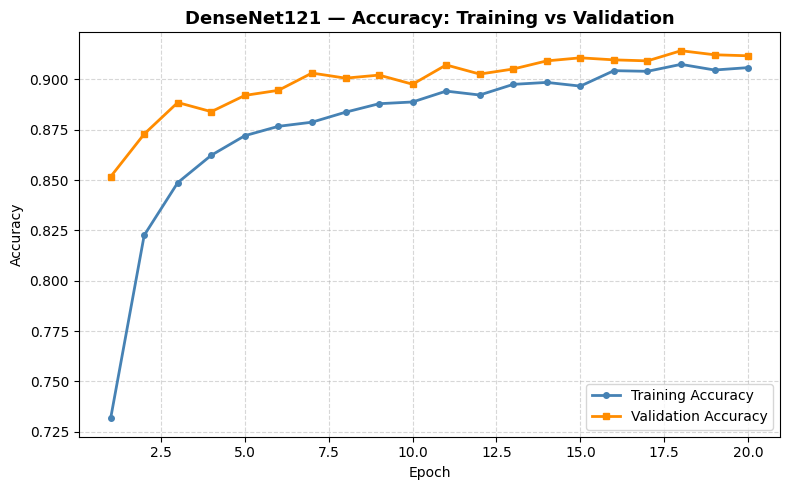

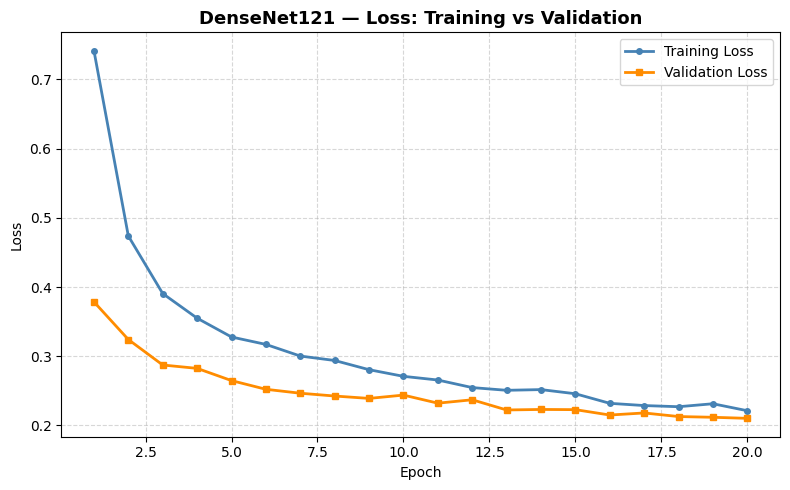


  DenseNet121 — FINAL TEST RESULTS
  Test Accuracy : 90.55%
  Test Loss     : 0.2154

Classification Report (DenseNet121):
              precision    recall  f1-score   support

      entero       0.85      0.80      0.82       504
      mancha       0.96      0.97      0.97       494
    quebrado       0.98      0.97      0.98       492
        tiza       0.83      0.89      0.86       499

    accuracy                           0.91      1989
   macro avg       0.91      0.91      0.91      1989
weighted avg       0.91      0.91      0.91      1989



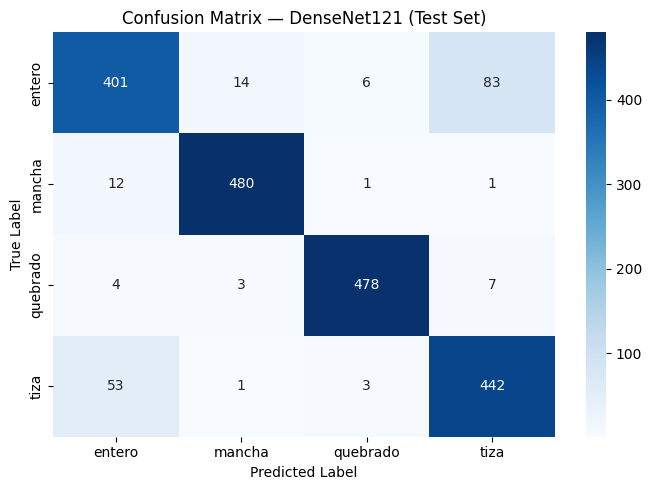

In [ ]:
# ============================================================
# MODELO 4: Gráficas y evaluación final — DenseNet121
# ============================================================
# Dos figuras separadas: Accuracy y Loss
plot_history(history_densenet, 'DenseNet121')

# Evaluación única y definitiva sobre el set de prueba
evaluate_on_test(model_densenet, 'DenseNet121')

# InceptionV3

In [ ]:
# ============================================================
# MODELO 5: Arquitectura InceptionV3
# ============================================================
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

# Generadores con el preprocesamiento nativo de InceptionV3
train_datagen_inc = ImageDataGenerator(preprocessing_function=inception_preprocess)
val_datagen_inc   = ImageDataGenerator(preprocessing_function=inception_preprocess)
test_datagen_inc  = ImageDataGenerator(preprocessing_function=inception_preprocess)

train_data_inc = train_datagen_inc.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_data_inc = val_datagen_inc.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

test_data_inc = test_datagen_inc.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

# Base preentrenada
base_inception = InceptionV3(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_inception.trainable = False

# Modelo completo
inputs = Input(shape=IMG_SIZE + (3,))
x = base_inception(inputs, training=False)   # importante
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model_inception = Model(inputs, outputs)

model_inception.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable = sum(tf.size(w).numpy() for w in model_inception.trainable_weights)
total = model_inception.count_params()
print(f"InceptionV3 — Total params: {total:,} | Trainable: {trainable:,}")


Found 9260 images belonging to 4 classes.
Found 1982 images belonging to 4 classes.
Found 1989 images belonging to 4 classes.
InceptionV3 — Total params: 22,361,764 | Trainable: 558,468


In [ ]:
# ============================================================
# MODELO 5: Entrenamiento InceptionV3
# ============================================================
print("--- STARTING TRAINING: InceptionV3 ---")
history_inception = model_inception.fit(
    train_data_inc,
    epochs          = EPOCHS,
    validation_data = val_data_inc,
    callbacks       = get_callbacks('inceptionv3')
)
print("--- TRAINING COMPLETE: InceptionV3 ---")

--- STARTING TRAINING: InceptionV3 ---
Epoch 1/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 70s 192ms/step - accuracy: 0.7584 - loss: 0.6522 - val_accuracy: 0.8602 - val_loss: 0.3558 - learning_rate: 1.0000e-04
Epoch 2/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 38s 132ms/step - accuracy: 0.8483 - loss: 0.3978 - val_accuracy: 0.8774 - val_loss: 0.3131 - learning_rate: 1.0000e-04
Epoch 3/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 37s 129ms/step - accuracy: 0.8684 - loss: 0.3321 - val_accuracy: 0.8754 - val_loss: 0.3105 - learning_rate: 1.0000e-04
Epoch 4/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 39s 135ms/step - accuracy: 0.8799 - loss: 0.3084 - val_accuracy: 0.8860 - val_loss: 0.2919 - learning_rate: 1.0000e-04
Epoch 5/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 39s 135ms/step - accuracy: 0.8884 - loss: 0.2912 - val_accuracy: 0.8971 - val_loss: 0.2740 - learning_rate: 1.0000e-04
Epoch 6/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 40s 138ms/step - accuracy: 0.8892 - loss: 0.2761 - val_accuracy: 0.9006 - val_loss: 0.2644 - learning_rate: 1.0000e-04
Epoch 7

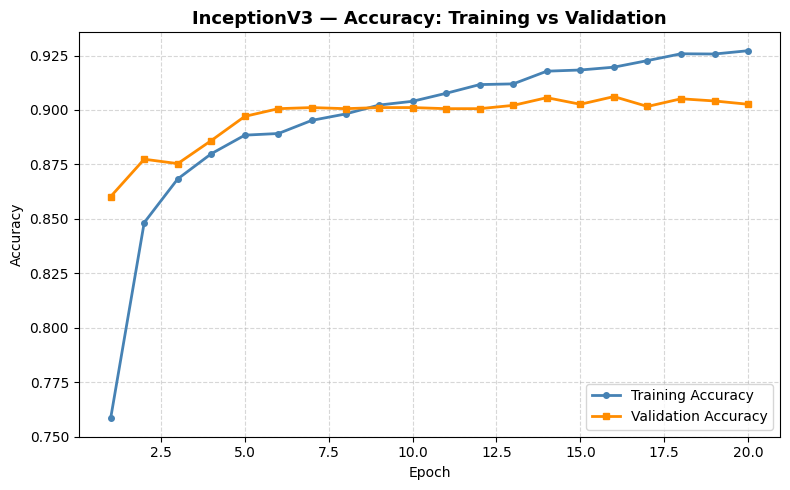

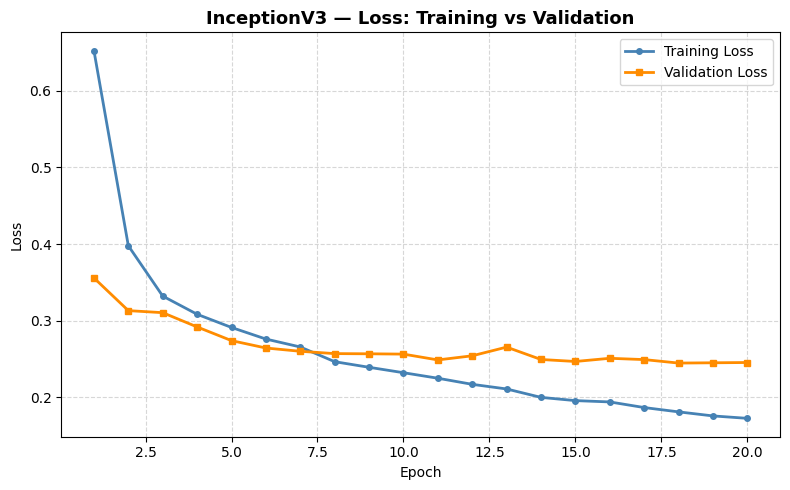


  InceptionV3 — FINAL TEST RESULTS
  Test Accuracy : 88.24%
  Test Loss     : 0.2957

Classification Report (InceptionV3):
              precision    recall  f1-score   support

      entero       0.84      0.74      0.78       504
      mancha       0.98      0.92      0.95       494
    quebrado       0.93      0.98      0.96       492
        tiza       0.79      0.89      0.84       499

    accuracy                           0.88      1989
   macro avg       0.88      0.88      0.88      1989
weighted avg       0.88      0.88      0.88      1989



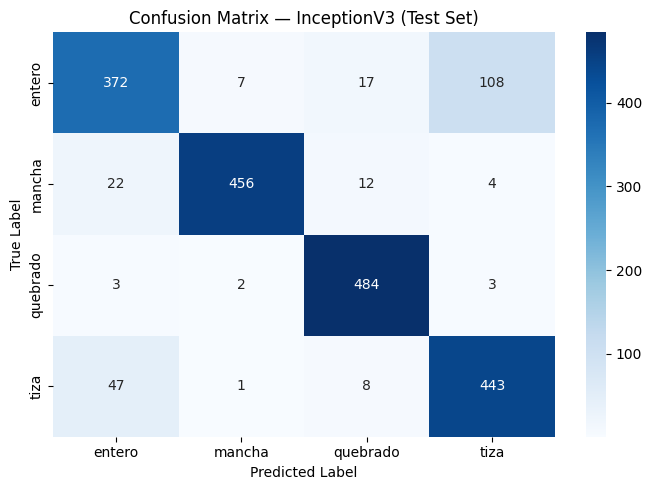

In [ ]:
# ============================================================
# MODELO 5: Gráficas y evaluación final — InceptionV3
# ============================================================
# Dos figuras separadas: Accuracy y Loss (Training vs Validation)
plot_history(history_inception, 'InceptionV3')

# Evaluación única y definitiva sobre el set de prueba
evaluate_on_test(model_inception, 'InceptionV3')